In [28]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10

In [4]:
((train_images,train_labels),(test_images,test_labels))= cifar10.load_data()

In [5]:
train_images= train_images/255.0
test_images= test_images/255.0

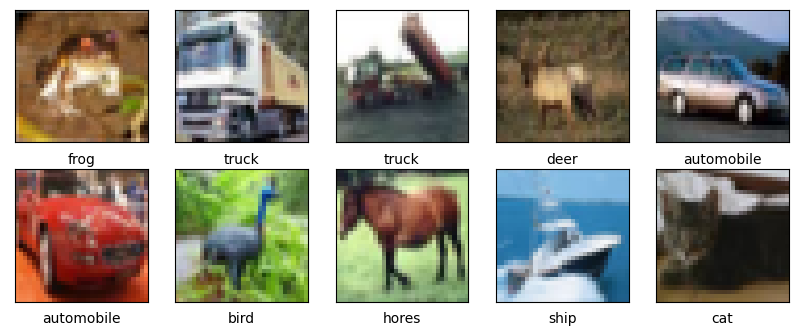

In [27]:
#showing images of mentioned categories
class_names= ['aeroplane','automobile','bird','cat','deer','dog','frog','hores','ship','truck']
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [29]:
#defining model architecture

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 1024)              0

In [30]:
#training model
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

epochs = 10
h = model.fit(train_images, train_labels, epochs=epochs,validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 [==============================] - 69s 40ms/step - loss: 1.5639 - accuracy: 0.4299 - val_loss: 1.2583 - val_accuracy: 0.5507
Epoch 2/10
1563/1563 [==============================] - 52s 33ms/step - loss: 1.2002 - accuracy: 0.5709 - val_loss: 1.1113 - val_accuracy: 0.6085
Epoch 3/10
1563/1563 [==============================] - 58s 37ms/step - loss: 1.0609 - accuracy: 0.6258 - val_loss: 1.0332 - val_accuracy: 0.6364
Epoch 4/10
1563/1563 [==============================] - 57s 37ms/step - loss: 0.9687 - accuracy: 0.6601 - val_loss: 0.9717 - val_accuracy: 0.6557
Epoch 5/10
1563/1563 [==============================] - 52s 33ms/step - loss: 0.9023 - accuracy: 0.6863 - val_loss: 0.9433 - val_accuracy: 0.6749
Epoch 6/10
1563/1563 [==============================] - 48s 31ms/step - loss: 0.8502 - accuracy: 0.7032 - val_loss: 0.8956 - val_accuracy: 0.6871
Epoch 7/10
1563/1563 [==============================] - 49s 31ms/step - loss: 0.8002 - accuracy: 0.7190 - val_loss: 0.8720 -

In [43]:
predicted_values = model.predict(test_images)
predicted_values.shape

313/313 [==============================] - 2s 6ms/step


(10000, 10)

Text(0.5, 1.0, 'hores')

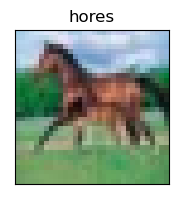

In [51]:
import random
import numpy as np
plt.figure(figsize=(2,2))
n = random.randint(0,9999)
#plt.figure(figsize=(10,10))
plt.imshow(test_images[n])
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title(class_names[np.argmax(predicted_values[n])])

In [44]:
test_loss,test_acc = model.evaluate(test_images,test_labels)
print("loss %.3f"%test_loss)
print("acc %.3f"%test_acc)


313/313 [==============================] - 2s 6ms/step - loss: 0.8607 - accuracy: 0.7060
loss 0.861
acc 0.706
